In [3]:
# Load the ECG data
data = np.loadtxt('data/ECGu.txt')

# Display it
print (data)
print("Number of points:", len(data))

[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
Number of points: 6500


# Arrival point : 
Detect heartbeats and compute heart rate from the raw ECG signal.

# Starting point : 
Raw voltage values loaded from 'ECGu.txt'

# Steps : 
1. Load the data
2. Plot the raw ECG data
3. Convert to mV / seconds
4. Plot rescaled data 
5. Rename vars, refactor, docstrings


In [4]:
import numpy as np  
import matplotlib.pyplot as plt

In [9]:
raw_ecg = np.loadtxt('data/ECGu.txt')

In [10]:
print(raw_ecg)
print(raw_ecg.shape)

[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
(6500, 3)


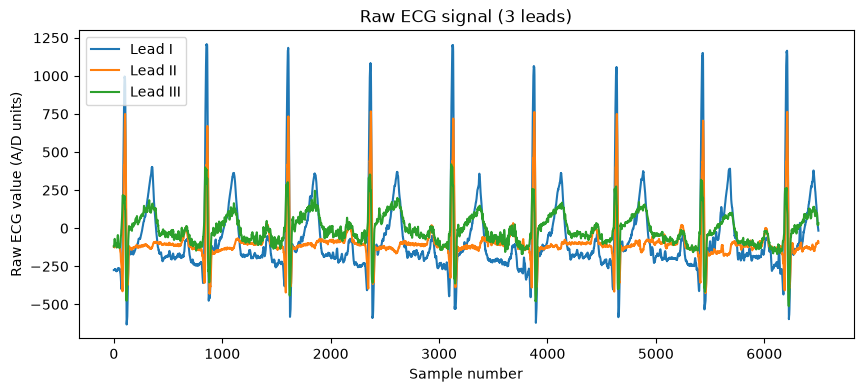

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(raw_ecg)
plt.xlabel("Sample number")
plt.ylabel("Raw ECG value (A/D units)")
plt.title("Raw ECG signal (3 leads)")
plt.legend(["Lead I", "Lead II", "Lead III"])
plt.show()

plt.figure(figsize=(10, 4)) - Crée une nouvelle figure (une nouvelle "fenêtre" de graphique) avec une taille de 10 pouces de large sur 4 pouces de haut. Sans ça, matplotlib utiliserait une taille par défaut (souvent trop petite/carrée), ce qui rendrait un signal ECG (qui s'étale sur l'axe du temps) difficile à lire.

plt.plot(raw_ecg) - Trace le graphique. raw_ecg est un tableau numpy de forme (6500, 3) — 6500 lignes (échantillons), 3 colonnes (leads I, II, III). Quand tu donnes un tableau 2D à plt.plot(), matplotlib trace automatiquement une courbe par colonne, en utilisant l'index de ligne (0, 1, 2, ..., 6499) comme axe des x. Résultat : 3 courbes superposées sur le même graphique, une par lead.

plt.xlabel("Sample number") - Ajoute un texte sous l'axe horizontal (x) pour dire ce qu'il représente : ici, le numéro de l'échantillon (0 à 6499), puisqu'on n'a pas encore converti ça en secondes.

plt.ylabel("Raw ECG value (A/D units)") : Ajoute un texte à côté de l'axe vertical (y) : les valeurs tracées sont les valeurs brutes du convertisseur analogique-numérique (A/D), pas encore converties en millivolts (d'où "raw" et "A/D units" — pas encore une unité physique réelle).

plt.title("Raw ECG signal (3 leads)") : Ajoute un titre en haut du graphique, pour que n'importe qui comprenne immédiatement ce que montre la figure sans avoir à lire le code.


plt.legend(["Lead I", "Lead II", "Lead III"]) : Ajoute une légende (petite boîte) qui associe chaque couleur de courbe à un nom. Comme plt.plot() a tracé 3 courbes dans l'ordre des colonnes de raw_ecg, cette liste doit être dans le même ordre : colonne 0 = Lead I, colonne 1 = Lead II, colonne 2 = Lead III.

plt.show() : Affiche le graphique final à l'écran.

In [15]:
print("Min value:", raw_ecg.min())
print("Max value:", raw_ecg.max())

Min value: -632.0
Max value: 1206.0


# Check : 
The plot shows 3 overlapping curves, one per lead, which matches raw_ecg.shape = (6500, 3). 
The x-axis goes up to 6500 samples as expected. 
The y-axis values range roughly from -500 to 1250, which is 
consistent with value check just performed. The signal shows a repeating pattern typical of heartbeats, rather than random noise, which suggests the data was loaded and plotted correctly.

In [20]:
# Convert raw ECG values to millivolts
# A/D converter gain: 1.024 µV per unit
AD_GAIN_UV = 1.024  # microvolts per raw unit
ecg_mV = raw_ecg * AD_GAIN_UV / 1000  # convert to millivolts

**Do we have the needed time information in our data?**

No. The raw data file `ECGu.txt` only contains 3 columns (the values for Lead I, II, and III) — there is no timestamp column. Since the time information is not directly available, we cannot simply divide an  existing column by 1000 as the formula in 5.1.2 suggests.

Instead, we reconstruct the time axis ourselves using the known sampling frequency (1000 Hz): each sample corresponds to 1/1000th of a second, so the time of sample `i` is `i / 1000` seconds. This is what `time_axis_s = np.arange(n_samples) / SAMPLING_FREQ_HZ` computes.

In [21]:
# Build the time axis in seconds
# Sampling frequency: 1000 Hz
SAMPLING_FREQ_HZ = 1000
n_samples = raw_ecg.shape[0]
time_axis_s = np.arange(n_samples) / SAMPLING_FREQ_HZ

n_samples = raw_ecg.shape[0] : Récupère le nombre total d'échantillons dans tes données.
raw_ecg.shape donne la forme complète du tableau, ici (6500, 3).
.shape[0] prend le premier élément de ce tuple (collection ordonnée de valeurs entre parenthèses : 6500 = nb lignes et 3 = nb colonnes), donc 6500 — le nombre de lignes (= nombre d'échantillons dans le temps). 

In [22]:
print("ecg_mV range:", ecg_mV.min(), "to", ecg_mV.max())
print("time_axis_s range:", time_axis_s[0], "to", time_axis_s[-1], "seconds")

ecg_mV range: -0.647168 to 1.234944
time_axis_s range: 0.0 to 6.499 seconds


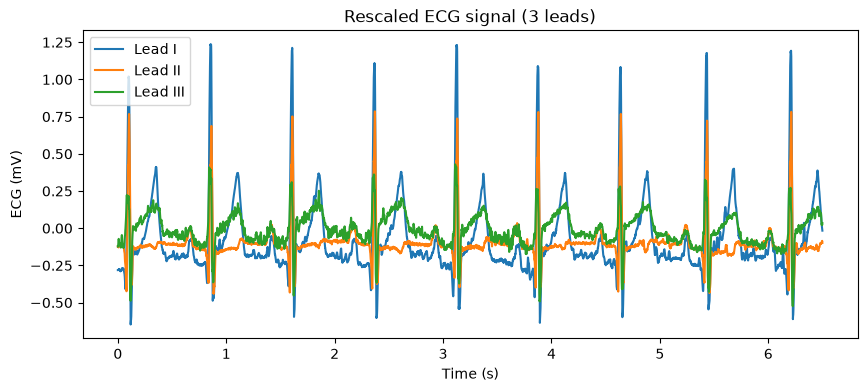

In [23]:
# Plot the rescaled ECG data
plt.figure(figsize=(10, 4))
plt.plot(time_axis_s, ecg_mV)
plt.xlabel("Time (s)")
plt.ylabel("ECG (mV)")
plt.title("Rescaled ECG signal (3 leads)")
plt.legend(["Lead I", "Lead II", "Lead III"])
plt.show()

plt.plot(time_axis_s, ecg_mV) — trace ecg_mV (y) en fonction de time_axis_s (x). Comme ecg_mV a 3 colonnes (une par lead), matplotlib trace automatiquement 3 courbes, chacune contre le même axe de temps.
plt.xlabel("Time (s)") — l'axe x est maintenant en secondes réelles, pas en numéro d'échantillon (différence avec 4.4).
plt.ylabel("ECG (mV)") — l'axe y est maintenant en millivolts, une vraie unité physique, pas en unités A/D brutes.
Le reste (titre, légende, figsize) est identique à la version brute.

# Checking the rescaled plot

**Are the number of timeseries correct?** 
3, matching `ecg_mV.shape[1] = 3` (Lead I, II, III).

**Are the number of samples correct?**
6500, matching `ecg_mV.shape[0]` and `len(time_axis_s)`.

**Are the values in the plot consistent with the expected range of ECG signals?** **What are the expected values for a normal ECG signal? Find a reference to support your answer.**
Approximately -0.65 to +1.25 mV. According to normal ECG  reference values (Rosenthal, L., *Normal Electrocardiography (ECG) Intervals*, Medscape, updated Jun 19, 2026 - https://emedicine.medscape.com/article/2172196-overview), a normal QRS amplitude is typically above 0.5 mV in standard leads, with an upper limit of normal around 2.5-3.0 mV. Our observed range fits comfortably within these bounds, supporting that the rescaling was done correctly.

**Other questions : Is the implied heart rate physiologically plausible?** 
Checking the sample count and value range only confirms the numbers are mathematically consistent — it doesn't confirm the signal actually looks like a real heartbeat. Since a real ECG shows a repeating pattern (one peak per heartbeat), we can cross-check the data by estimating the heart rate directly from the signal and comparing it to a known normal range (60-100 bpm at rest).

Here, visually counting the peaks on the plot over the 6.5-second window gives peaks, which corresponds to:

    9 peaks / 6.5 seconds × 60 seconds/minute ≈ 83 bpm

This falls within the normal resting heart rate range (60-100 bpm), which supports that the signal was loaded and rescaled correctly, and that it genuinely represents heartbeat activity rather than an arbitrary waveform.


# Refactoring: a reusable plotting function

The raw and rescaled ECG plots use almost identical code, differing only in axis labels, title, and data. To avoid duplication and make future changes easier (e.g. if we want to add more leads or change the plot style), we factor this into a single `plot_ecg` function.

In [41]:
def plot_ecg(time_axis, ecg_leads, title="ECG Signal", xlabel="Time (s)", ylabel="ECG (mV)",
             lead_names=("Lead I", "Lead II", "Lead III")):
    """Plot ECG signal(s) as a line chart with labeled axes, title, and legend.

    Used to avoid duplicating plotting code between the raw and rescaled 
    ECG plots — only the data and axis labels change between calls.

    One line is plotted per lead, using the column order in ecg_data 
    matched to the order of lead_names.
    """
    plt.figure(figsize=(10, 4))

    for i, lead_name in enumerate(lead_names):
        plt.plot(time_axis, ecg_leads[:, i], label=lead_name)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

### Explication de `plot_ecg`

def plot_ecg(time_axis, ecg_data, title="ECG Signal", xlabel="Time (s)", 
             ylabel="ECG (mV)", lead_names=("Lead I", "Lead II", "Lead III")):
→ time_axis et ecg_data sont obligatoires. Les autres ont une valeur par 
défaut, donc optionnels à l'appel.

"""..."""
→ Docstring : documentation de la fonction (ignorée à l'exécution).

plt.figure(figsize=(10, 4))
→ Crée une figure de 10x4 pouces.

for i, lead_name in enumerate(lead_names):
→ Parcourt chaque nom de lead avec son index (i = 0, 1, 2...).

    plt.plot(time_axis, ecg_data[:, i], label=lead_name)
→ ecg_data[:, i] = toutes les lignes, colonne i uniquement (un seul lead).
  Trace cette courbe avec son nom directement attaché via label=.

plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(title)
→ Ajoute les labels et le titre passés en paramètres.

plt.legend()
→ Affiche la légende, en récupérant automatiquement les label= de la boucle.

plt.show()
→ Affiche le graphique.

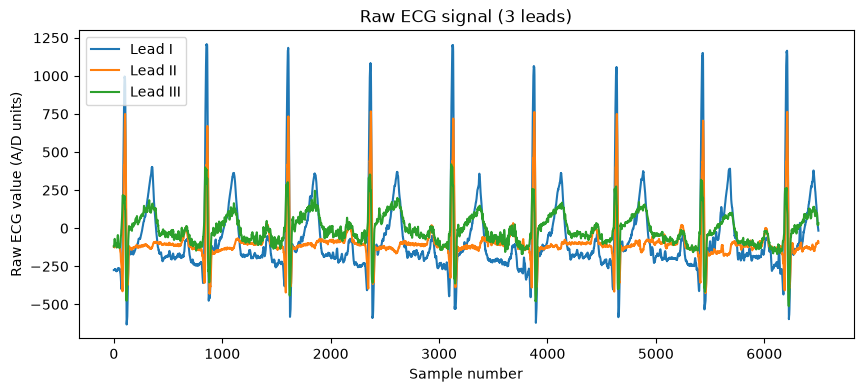

In [42]:
plot_ecg(
    time_axis=np.arange(raw_ecg.shape[0]),
    ecg_leads=raw_ecg,
    title="Raw ECG signal (3 leads)",
    xlabel="Sample number",
    ylabel="Raw ECG value (A/D units)"
)

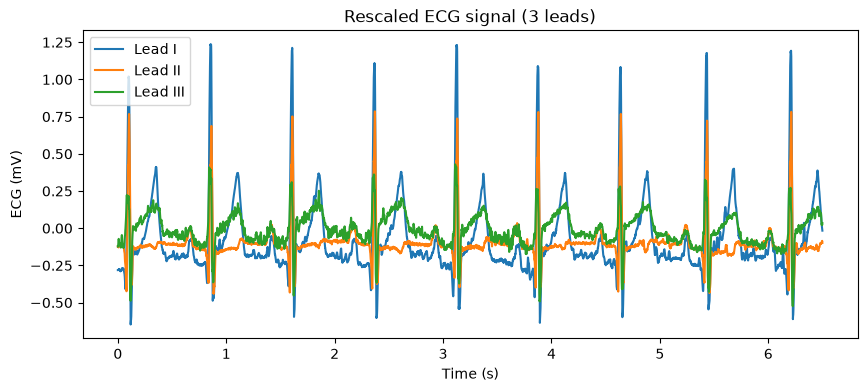

In [43]:
plot_ecg(
    time_axis=time_axis_s,
    ecg_leads=ecg_mV,
    title="Rescaled ECG signal (3 leads)",
    xlabel="Time (s)",
    ylabel="ECG (mV)"
)

In [44]:
def plot_grid(seconds_per_square, mV_per_square, alpha, min_time, max_time, min_ecg, max_ecg):
    """Draw a plain grid on the current matplotlib axes.

    Parameters
    ----------
    seconds_per_square : float
        Time interval between vertical grid lines, in seconds.
    mV_per_square : float
        Voltage interval between horizontal grid lines, in millivolts.
    alpha : float
        Transparency of the grid lines (0.0 = invisible, 1.0 = opaque).
    min_time, max_time : float
        Time range covered by the grid, in seconds.
    min_ecg, max_ecg : float
        ECG value range covered by the grid, in millivolts.
    """
    for t in np.arange(min_time, max_time, seconds_per_square):
        plt.axvline(t, color="red", alpha=alpha, linewidth=0.5)
    for v in np.arange(min_ecg, max_ecg, mV_per_square):
        plt.axhline(v, color="red", alpha=alpha, linewidth=0.5)

### Explication de `plot_grid`

def plot_grid(seconds_per_square, mV_per_square, alpha, min_time, max_time, min_ecg, max_ecg):
→ Fonction générique pour dessiner une grille, sans logique ECG spécifique 
  (elle sera réutilisée par plot_ecg_grid avec des valeurs particulières).

for t in np.arange(min_time, max_time, seconds_per_square):
→ Génère une série de temps espacés de seconds_per_square, entre min_time 
  et max_time (ex: 0, 0.2, 0.4, 0.6... si seconds_per_square=0.2).

    plt.axvline(t, color="red", alpha=alpha, linewidth=0.5)
→ Trace une ligne verticale à chaque temps t, sur toute la hauteur du graphique. 
  alpha contrôle la transparence (grille légère, pas envahissante).

for v in np.arange(min_ecg, max_ecg, mV_per_square):
→ Pareil que ci-dessus mais pour l'axe vertical : génère des valeurs de mV 
  espacées de mV_per_square.

    plt.axhline(v, color="red", alpha=alpha, linewidth=0.5)
→ Trace une ligne horizontale à chaque valeur v, sur toute la largeur du graphique.

In [45]:
def plot_ecg_grid(min_time, max_time, min_ecg, max_ecg):
    """Draw a classical ECG paper grid on the current matplotlib axes.

    Major lines every 0.2s / 0.5mV (darker), minor lines every 
    0.04s / 0.1mV, i.e. 1/5 of the major spacing (lighter), 
    matching standard ECG paper conventions.
    """
    plot_grid(seconds_per_square=0.2, mV_per_square=0.5, alpha=0.5,
              min_time=min_time, max_time=max_time, min_ecg=min_ecg, max_ecg=max_ecg)
    plot_grid(seconds_per_square=0.2 / 5, mV_per_square=0.5 / 5, alpha=0.2,
              min_time=min_time, max_time=max_time, min_ecg=min_ecg, max_ecg=max_ecg)

### Explication de `plot_ecg_grid`

def plot_ecg_grid(min_time, max_time, min_ecg, max_ecg):
→ Cette fonction ne prend pas seconds_per_square/mV_per_square en paramètre, 
  car elle impose les valeurs standard d'une grille ECG classique (0.2s/0.5mV).

plot_grid(seconds_per_square=0.2, mV_per_square=0.5, alpha=0.5, ...)
→ Premier appel : dessine la grille "principale" (grosses cases), tous les 
  0.2 secondes et 0.5 mV, avec une opacité de 0.5 (assez visible).

plot_grid(seconds_per_square=0.2 / 5, mV_per_square=0.5 / 5, alpha=0.2, ...)
→ Deuxième appel : dessine la grille "fine" (petites cases), 5 fois plus 
  rapprochée (0.04s/0.1mV), avec une opacité plus faible (0.2 = plus discrète), 
  pour imiter le papier millimétré classique des ECG.

→ On réutilise plot_grid deux fois avec des paramètres différents, plutôt 
  que de dupliquer le code de dessin de grille : c'est un exemple direct 
  d'élimination de duplication (section 6.1).

In [46]:
def plot_one_ecg_signal(time, ecg, lead_name, color):
    """Plot a single ECG lead's signal over time on the current axes.

    Parameters
    ----------
    time : array-like
        Time values for the ECG signal, in seconds.
    ecg : array-like
        ECG signal values for this lead, in millivolts.
    lead_name : str
        Name of the lead (used as the plot legend label).
    color : str
        Color used to draw the signal line.
    """
    plt.plot(time, ecg, color=color, label=lead_name, linewidth=1)

### Explication de `plot_one_ecg_signal`

def plot_one_ecg_signal(time, ecg, lead_name, color):
→ Fonction volontairement simple : elle ne trace qu'UNE seule courbe 
  (un seul lead), pas plusieurs — une seule tâche claire par fonction.

plt.plot(time, ecg, color=color, label=lead_name, linewidth=1)
→ Trace la courbe du signal ECG, avec :
  - color : couleur choisie pour cette ligne
  - label=lead_name : nom utilisé automatiquement dans la légende
  - linewidth=1 : épaisseur fine, pour rester lisible même avec la grille en fond

In [51]:
def plot_one_lead_in_subplots(subplot, time, ecg, lead_name, color, min_ecg=None, max_ecg=None):
    """Plot one ECG lead, with its grid, into a subplot slot.

    Combines plot_ecg_grid and plot_one_ecg_signal into a single 
    labeled subplot, mimicking one channel of a real ECG monitor.

    Parameters
    ----------
    subplot : int
        Subplot index (1, 2, or 3) among a 3-row column of subplots.
    time : array-like
        Time values for the ECG signal, in seconds.
    ecg : array-like
        ECG signal values for this lead, in millivolts.
    lead_name : str
        Name of the lead.
    color : str
        Color used to draw the signal line.
    min_ecg, max_ecg : float, optional
        Shared y-axis range to use across leads. If not given, the 
        range is computed from this lead's own data only.
    """
    if min_ecg is None:
        min_ecg = ecg.min()
    if max_ecg is None:
        max_ecg = ecg.max()

    plt.subplot(3, 1, subplot)
    plot_ecg_grid(min_time=time.min(), max_time=time.max(),
                  min_ecg=min_ecg, max_ecg=max_ecg)
    plot_one_ecg_signal(time, ecg, lead_name, color)
    plt.ylabel(f"{lead_name}\n(mV)")
    plt.legend(loc="upper right")

### Explication de `plot_one_lead_in_subplots`

plt.subplot(3, 1, subplot)
→ Sélectionne la zone de dessin actuelle : une grille de 3 lignes, 1 colonne 
  de sous-graphiques, et on se place dans le sous-graphique numéro "subplot" 
  (1, 2 ou 3).

plot_ecg_grid(min_time=time.min(), max_time=time.max(), 
              min_ecg=ecg.min(), max_ecg=ecg.max())
→ Dessine la grille ECG en arrière-plan, adaptée exactement à la plage de 
  temps et de valeurs de CE lead précis (min/max calculés directement à 
  partir des données passées).

plot_one_ecg_signal(time, ecg, lead_name, color)
→ Trace la courbe du signal par-dessus la grille, en réutilisant la 
  fonction déjà créée (encore un exemple d'éviter la duplication).

plt.ylabel(f"{lead_name}\n(mV)")
→ Ajoute le nom du lead comme label de l'axe y, avec l'unité (mV) sur une 
  nouvelle ligne (le \n crée un retour à la ligne dans le texte).

plt.legend(loc="upper right")
→ Affiche la légende (nom du lead) dans le coin supérieur droit du subplot.

→ Cette fonction "assemble" deux fonctions plus simples (grille + signal) 
  pour créer un sous-graphique complet — bon exemple de décomposition en 
  petites fonctions avec une tâche claire chacune (section 6.1).
  ### Mise à jour de `plot_one_lead_in_subplots`

def plot_one_lead_in_subplots(subplot, time, ecg, lead_name, color, min_ecg=None, max_ecg=None):
→ Ajout de deux nouveaux paramètres optionnels : min_ecg et max_ecg. 
  "Optionnel" veut dire qu'on peut appeler la fonction sans les préciser, 
  comme avant.

if min_ecg is None:
    min_ecg = ecg.min()
if max_ecg is None:
    max_ecg = ecg.max()
→ Si min_ecg/max_ecg ne sont pas fournis (valeur par défaut None), la 
  fonction calcule l'échelle à partir des données du lead courant, comme 
  avant. Mais si on lui donne des valeurs (calculées ailleurs, sur tous 
  les leads), elle les utilise à la place — ce qui permet de partager une 
  même échelle entre plusieurs subplots.

→ Le reste de la fonction (plt.subplot, plot_ecg_grid, plot_one_ecg_signal, 
  plt.ylabel, plt.legend) ne change pas.

**Pourquoi ce changement ?**
Cette petite modification permet de réutiliser exactement la même fonction 
pour deux besoins différents

In [48]:
def plot_all_leads_in_subplots(time, ecg, lead_names, colors):
    """Plot all ECG leads, each in its own subplot with a matching grid,
    mimicking the appearance of a real multi-lead ECG monitor.

    Parameters
    ----------
    time : array-like
        Time values for the ECG signal, in seconds.
    ecg : array-like
        ECG signal values for all leads (shape: n_samples x n_leads).
    lead_names : list of str
        Names of the ECG leads, e.g. ["Lead I", "Lead II", "Lead III"].
    colors : list of str
        Colors used for each lead's line, matched by position to lead_names.
    """
    plt.figure(figsize=(10, 8))
    for i, (lead_name, color) in enumerate(zip(lead_names, colors), start=1):
        plot_one_lead_in_subplots(i, time, ecg[:, i - 1], lead_name, color)
    plt.xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

### Explication de `plot_all_leads_in_subplots`

plt.figure(figsize=(10, 8))
→ Crée une figure plus haute (8 pouces) que d'habitude, car elle va 
  contenir 3 sous-graphiques empilés verticalement.

for i, (lead_name, color) in enumerate(zip(lead_names, colors), start=1):
→ zip(lead_names, colors) associe chaque nom de lead à sa couleur, 
  1 par 1 (ex: ("Lead I", "black"), ("Lead II", "black")...).
  enumerate(..., start=1) ajoute un compteur i qui commence à 1 (pas 0), 
  pour correspondre directement aux indices 1/2/3 attendus par 
  plot_one_lead_in_subplots.

    plot_one_lead_in_subplots(i, time, ecg[:, i - 1], lead_name, color)
→ Appelle la fonction précédente pour CE lead précis. 
  ecg[:, i - 1] sélectionne la bonne colonne : comme i commence à 1 mais 
  les colonnes du tableau commencent à l'index 0, on fait i - 1 pour 
  bien faire correspondre subplot 1 → colonne 0, subplot 2 → colonne 1, etc.

plt.xlabel("Time (s)")
→ Ajoute un seul label d'axe x, sous le dernier subplot (partagé visuellement 
  pour toute la figure).

plt.tight_layout()
→ Ajuste automatiquement l'espacement entre les subplots pour éviter que 
  les titres/labels se chevauchent.

plt.show()
→ Affiche la figure complète avec les 3 subplots.

→ Cette fonction est la plus "haut niveau" : elle ne dessine rien elle-même, 
  elle orchestre les autres fonctions (plot_one_lead_in_subplots, qui elle-même 
  utilise plot_ecg_grid et plot_one_ecg_signal). C'est une architecture en 
  couches : chaque fonction a un rôle précis et s'appuie sur les précédentes.

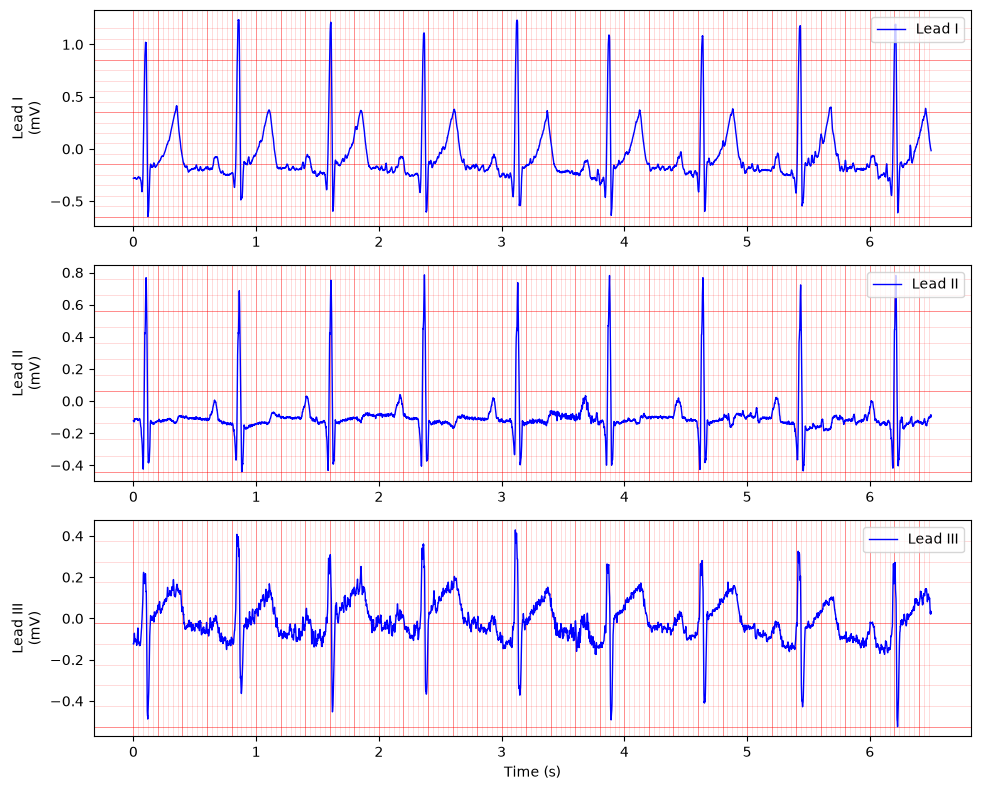

In [50]:
plot_all_leads_in_subplots(
    time=time_axis_s,
    ecg=ecg_mV,
    lead_names=["Lead I", "Lead II", "Lead III"],
    colors=["blue", "blue", "blue"]
)

### Test de `plot_all_leads_in_subplots`

On appelle la fonction avec les données rescalées (time_axis_s, ecg_mV) et 
les 3 noms de leads. On peut changer les couleurs facilement en modifiant 
juste la liste `colors` (ex: ["black", "blue", "green"]), sans toucher au 
code des fonctions.

In [52]:
def plot_all_leads_in_subplots_shared_scale(time, ecg, lead_names, colors):
    """Plot all ECG leads, each in its own subplot, sharing the same 
    y-axis scale across all leads (unlike plot_all_leads_in_subplots, 
    which scales each lead independently).

    Sharing the scale allows visually comparing the amplitude between 
    leads, as on a real multi-lead ECG monitor.

    Parameters
    ----------
    time : array-like
        Time values for the ECG signal, in seconds.
    ecg : array-like
        ECG signal values for all leads (shape: n_samples x n_leads).
    lead_names : list of str
        Names of the ECG leads, e.g. ["Lead I", "Lead II", "Lead III"].
    colors : list of str
        Colors used for each lead's line, matched by position to lead_names.
    """
    min_ecg, max_ecg = ecg.min(), ecg.max()

    plt.figure(figsize=(10, 8))
    for i, (lead_name, color) in enumerate(zip(lead_names, colors), start=1):
        plot_one_lead_in_subplots(i, time, ecg[:, i - 1], lead_name, color,
                                    min_ecg=min_ecg, max_ecg=max_ecg)
    plt.xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

### Nouvelle fonction : `plot_all_leads_in_subplots_shared_scale`

def plot_all_leads_in_subplots_shared_scale(time, ecg, lead_names, colors):
→ Même signature que plot_all_leads_in_subplots (fonction 5), mais avec un 
  comportement différent pour l'échelle verticale.

min_ecg, max_ecg = ecg.min(), ecg.max()
→ Calcule le minimum et le maximum sur TOUT le tableau ecg, donc sur les 
  3 leads confondus (contrairement à avant, où c'était calculé lead par 
  lead séparément).

for i, (lead_name, color) in enumerate(zip(lead_names, colors), start=1):
    plot_one_lead_in_subplots(i, time, ecg[:, i - 1], lead_name, color,
                                min_ecg=min_ecg, max_ecg=max_ecg)
→ Appelle plot_one_lead_in_subplots pour chaque lead, mais cette fois en 
  lui passant explicitement min_ecg et max_ecg (les valeurs globales 
  calculées juste avant), donc les 3 subplots auront la MÊME échelle 
  verticale.

**Pourquoi cette fonction existe :**
Elle ne duplique aucun code de dessin — elle réutilise entièrement 
plot_one_lead_in_subplots, juste avec des paramètres différents. C'est 
un bon exemple de comment un petit ajout de paramètres optionnels (voir 
ci-dessus) permet de créer un nouveau comportement sans dupliquer de code.

### Différence entre les deux plots ECG

**`plot_all_leads_in_subplots`** (échelle par lead) : chaque subplot a sa 
propre échelle verticale, calculée à partir des valeurs min/max de ce 
lead uniquement. Avantage : chaque signal utilise tout l'espace vertical 
disponible, ce qui peut rendre les petits détails plus visibles sur les 
leads à faible amplitude (comme Lead III). Inconvénient : on ne peut pas 
comparer visuellement l'amplitude entre les leads, car les échelles ne 
sont pas les mêmes.

**`plot_all_leads_in_subplots_shared_scale`** (échelle partagée) : les 
3 subplots utilisent la même échelle verticale (min/max calculés sur 
tous les leads ensemble). Avantage : on peut comparer directement 
l'amplitude entre les leads (par exemple, voir que Lead I a un pic R 
plus grand que Lead III), ce qui correspond à la façon dont un vrai 
moniteur ECG clinique affiche les leads. Inconvénient : les leads de 
faible amplitude paraissent visuellement plus "écrasés" dans leur subplot.

**Conclusion :** les deux versions sont utiles selon l'objectif — 
l'échelle par lead pour l'analyse détaillée d'un seul lead, l'échelle 
partagée pour la comparaison clinique entre leads.

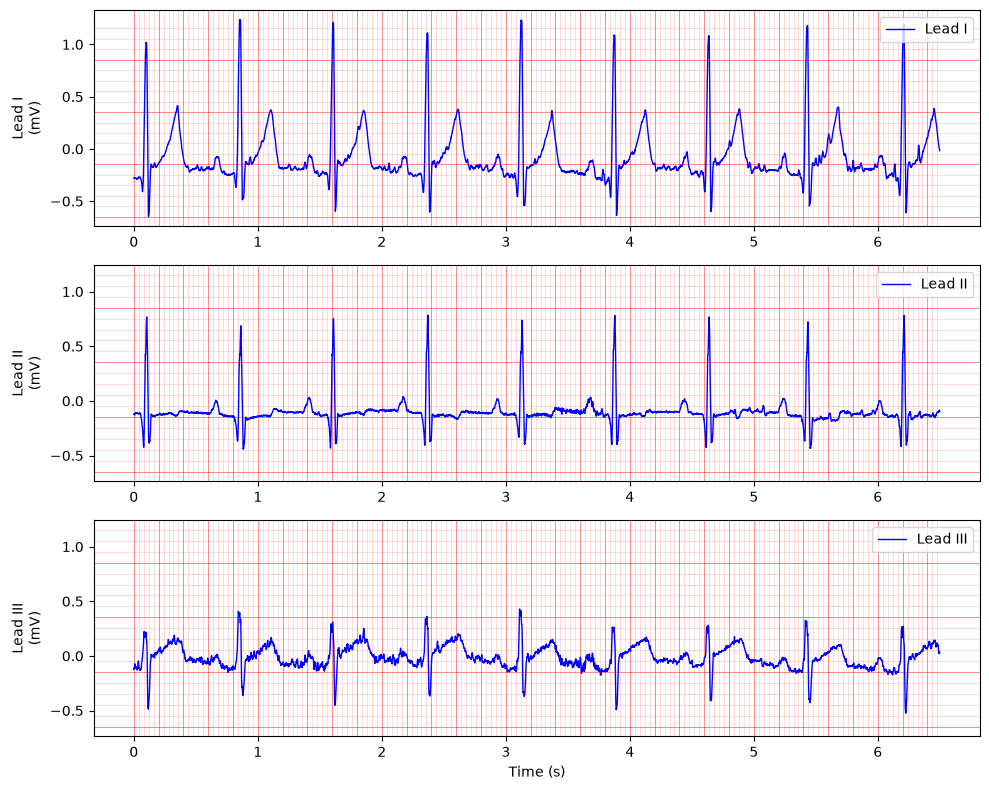

In [54]:
plot_all_leads_in_subplots_shared_scale(
    time=time_axis_s, ecg=ecg_mV,
    lead_names=["Lead I", "Lead II", "Lead III"],
    colors=["blue", "blue", "blue"]
)